# Circle Detection with Hough Circles

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
%matplotlib inline

In [68]:
"""
Steps:

1. Canny Edge Detection
   - uses cv2 here; everything else is implemented from scratch for better understanding

2. Create and Populate the 3D Accumulator Array (a, b, r)
   - a circle is defined by its center (a, b) and radius r:
     (x - a)^2 + (y - b)^2 = r^2
   - for each radius r in [r_min, r_max], each edge pixel (x, y) votes for
     every center (a, b) that is at distance r from it:
     a = x - r*cos(theta),  b = y - r*sin(theta)
   - i.e. each edge pixel draws a circle of votes in (a, b) space for every r

3. Peak Detection with Non-Max Suppression
   - threshold: keep only cells with at least `threshold` votes
     (can be normalized by circumference, 2*pi*r, so large circles
     aren't favored just for having more edge pixels)
   - suppress close peaks: keep a cell only if it is the maximum in its
     (a, b, r) neighborhood, so one real circle doesn't produce several
     nearly identical detections (slightly shifted centers or radii)

4. Draw Circles
   - convert each (a, b, r) peak back to image coordinates and draw the
     circle with center (a, b) and radius r
"""

"\nSteps:\n\n1. Canny Edge Detection\n   - uses cv2 here; everything else is implemented from scratch for better understanding\n\n2. Create and Populate the 3D Accumulator Array (a, b, r)\n   - a circle is defined by its center (a, b) and radius r:\n     (x - a)^2 + (y - b)^2 = r^2\n   - for each radius r in [r_min, r_max], each edge pixel (x, y) votes for\n     every center (a, b) that is at distance r from it:\n     a = x - r*cos(theta),  b = y - r*sin(theta)\n   - i.e. each edge pixel draws a circle of votes in (a, b) space for every r\n\n3. Peak Detection with Non-Max Suppression\n   - threshold: keep only cells with at least `threshold` votes\n     (can be normalized by circumference, 2*pi*r, so large circles\n     aren't favored just for having more edge pixels)\n   - suppress close peaks: keep a cell only if it is the maximum in its\n     (a, b, r) neighborhood, so one real circle doesn't produce several\n     nearly identical detections (slightly shifted centers or radii)\n\n4.

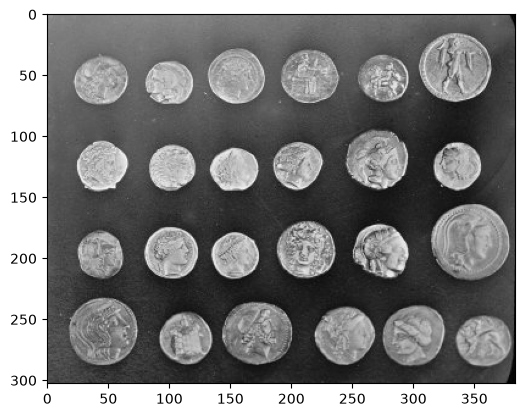

In [69]:
from skimage import data

image = data.coins()     # grayscale uint8, shape (303, 384)
plt.imshow(coins, cmap="gray")

## Step 1: Edge Detection

The image is converted to grayscale, blurred with a Gaussian to reduce noise, and passed through OpenCV's Canny detector. Only the resulting edge pixels vote in the next step.

Text(0.5, 1.0, 'canny edges')

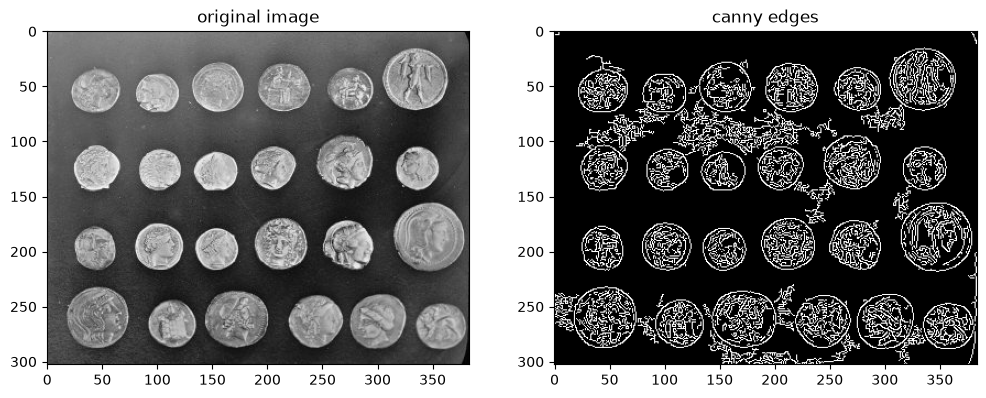

In [104]:
canny_edges = cv2.Canny(image, -1, 200, 255)

plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('original image')

plt.subplot(1, 2, 2)
plt.imshow(canny_edges, cmap='gray')
plt.title('canny edges')

Text(0.5, 1.0, 'canny edges')

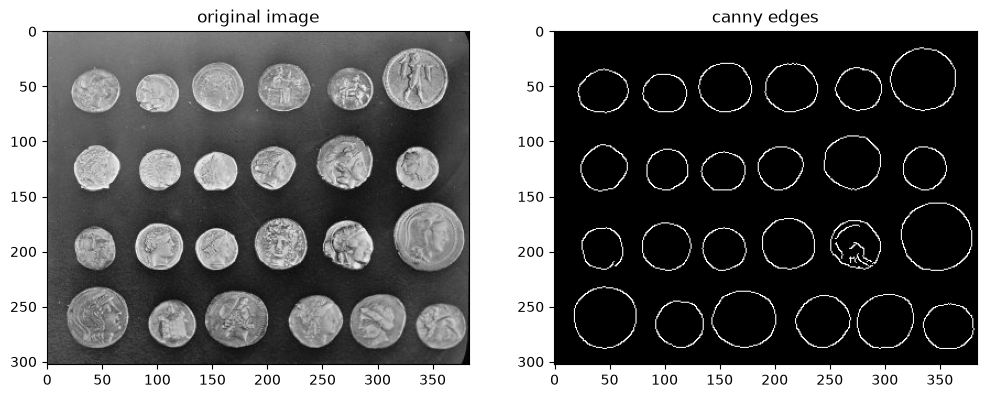

In [105]:
img_blur = cv2.GaussianBlur(image, ksize=(7,7), sigmaX=2, sigmaY=2)
canny_edges = cv2.Canny(img_blur, -1, 200, 255)

plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('original image')

plt.subplot(1, 2, 2)
plt.imshow(canny_edges, cmap='gray')
plt.title('canny edges')

In [133]:
def detect_edges(img, g_k=7, t1=200, t2=255):
    """
    Convert to grayscale, and return canny edges
    """
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) if img.ndim == 3 else img
    img_blur = cv2.GaussianBlur(image, ksize=(g_k, g_k), sigmaX=2, sigmaY=2)
    return cv2.Canny(img_blur, t1, t2)

## Step 2: Accumulator Array

A circle is defined by its center $(a, b)$ and radius $r$:

$$(x - a)^2 + (y - b)^2 = r^2$$

For each candidate radius $r$, every edge pixel $(x, y)$ could lie on a circle whose center is anywhere at distance $r$ from it. Each edge pixel votes along a circle of possible centers in a 3D accumulator indexed by $(b, a, r)$. Edge pixels on the same real circle all vote for its true center, which builds a strong peak there. 

To draw a circle in the accumulator array given an edge pixel $(x, y)$ and a radius $r$, We need the points that define the outer edge of the circle. Consider a unit circle centered at (0, 0), a point (a. b) that on it's edge given we know the center $(x, y)$, radius $r$ (1, in this case) and the angle $\theta$ which is the angle made by the line connecting the center to teh point $(a, b)$ on the edge can be given by the following equation: 

$$a = x - r\cos\theta, \qquad b = y - r\sin\theta, \qquad \theta \in [0°, 360°)$$

THis way we can find the pixels that rep[resent the edges of the circle, to draw the cirlce on teh accumulator arrar, i.e. accruing the vote.

In [87]:
def get_accumulator(canny_out, radii, theta_step=1):
    """
    Build the (b, a, r) accumulator: each edge pixel votes for all centers at distance r.
    """
    
    H, W = canny_out.shape

    thetas = np.arange(0, 2*np.pi, theta_step)
    cos_t, sin_t = np.cos(thetas), np.sin(thetas)
    Y, X = np.nonzero(canny_out)                               # edge pixels only

    acc = np.zeros((H, W, len(radii)), dtype=np.int32)     # one 2D accumulator array per radius

    for i, r in enumerate(radii):
        # (N, 1) - (T,) -> (N, T) broadcasting: candidate centers for every (edge pixel, theta) pair.
        # Row k of A and B holds the candidate centers (at radius r) for edge pixel (X[k], Y[k]).
        B = np.round(Y[:, None] - r * sin_t).astype(int)
        A = np.round(X[:, None] - r * cos_t).astype(int)

        # Keep only centers inside the image (negative indices would wrap).
        # Both row and column must be valid, so the conditions are combined with &.
        # (Chained comparisons like 0 <= A < W don't work on NumPy arrays.)
        valid = (A >= 0) & (A < W) & (B >= 0) & (B < H)

        # valid is a 2D boolean array, but A[valid] and B[valid] return the selected
        # values as 1D arrays, aligned element by element. np.add.at then adds one vote
        # at each (b, a, i); repeated coordinates each count, unlike acc[...] += 1.
        np.add.at(acc, (B[valid], A[valid], i), 1)

        """
        Loop equivalent of the vectorized code above (same result, much slower):
    
        for x, y in zip(X, Y):                       # each edge pixel
            for theta in thetas:                     # each angle
                b = int(round(y - r * np.sin(theta)))
                a = int(round(x - r * np.cos(theta)))
                if 0 <= a < W and 0 <= b < H:        # chained comparison is fine for scalars
                    acc[b, a, i] += 1                # one vote for center (a, b) at radius r
        """

    return acc

## Step 3: Peak Detection and Non-Max Suppression

The accumulator cells with the most votes are the most likely circles. Neighboring cells (slightly shifted centers or radii) also collect many votes from the same circle, so:

1. Candidates are sorted by vote count.
2. A candidate is accepted only if its center is more than `min_dist` pixels from every circle already accepted.
3. This stops once `n` circles have been found.

In [88]:
def get_n_largest_indices(arr, n):
    """
    Return (b, a, r_idx) indices of the n largest values.
    """
    n = min(n, arr.size)
    flat_topn_idxs = np.argpartition(arr.ravel(), -n)[-n:]            # n largest, unordered

    # get sorted indexes by value
    flat_topn_values = arr.ravel()[flat_topn_idxs]
    flat_topn_sorted_subidxs = np.argsort(-flat_topn_values)          # this is a sub index since we are sorting the topn subset of the arary
    flat_topn_sorted_idxs = flat_topn_idxs[flat_topn_sorted_subidxs]  # use sorted sub indices to sort original topn indices

    # get indices in 3D arrangement. np.unravel_index converts a flat index or array of flat indices into a tuple of coordinate arrays.
    b_idxs, a_idxs, r_idxs = np.unravel_index(flat_topn_sorted_idxs, arr.shape)

    # return top n center candidates as a list of tuples
    return list(zip(b_idxs, a_idxs, r_idxs))

    
def is_too_close(a, b, accepted, min_dist):
    """
    Return True if (a, b) is within min_dist of any accepted circle's center.
    """
    for a_kept, b_kept, _ in accepted:              # each circle already kept
        dist = np.hypot(a - a_kept, b - b_kept)     # distance between the two centers
        if dist <= min_dist:
            return True
    return False


def get_circle_detections(acc, radii, n, min_dist=10):
    """
    Pick the n strongest circles, skipping any whose center is within min_dist of a kept one.
    """
    # strongest candidates first; take extra since many will be suppressed as duplicates
    candidates = get_n_largest_indices(acc, n * 20)

    accepted = []
    for b, a, r_idx in candidates:                  # one candidate circle at a time

        # non-max suppression: a stronger circle was already kept nearby -> duplicate
        if is_too_close(a, b, accepted, min_dist):
            continue

        accepted.append((a, b, radii[r_idx]))       # store center and actual radius

        if len(accepted) == n:                      # stop once we have n circles
            break

    return accepted

## Step 4: Draw Circles

Each detection $(a, b, r)$ is drawn directly as a circle with center $(a, b)$ and radius $r$ on a copy of the original image.

In [146]:
def draw_circles(img, circles, color=(0, 255, 0), thickness=1):
    """
    Draw (a, b, r) circles on an RGB copy of the image.
    """
    
    out = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) if img.ndim == 2 else img.copy()
    for a, b, r in circles:
        cv2.circle(out, (int(a), int(b)), int(r), color, thickness)
        
    return out


def get_hough_circles(img, g_k=7, th1=50, th2=150, n=24, radii=range(15, 40, 2), min_dist=15):
    """
    Run the full pipeline and return the image with detected circles drawn.
    """
    
    edges = detect_edges(img, g_k, th1, th2)
    acc = get_accumulator(edges, radii)
    circles = get_circle_detections(acc, radii, n, min_dist)
    
    return draw_circles(img, circles)

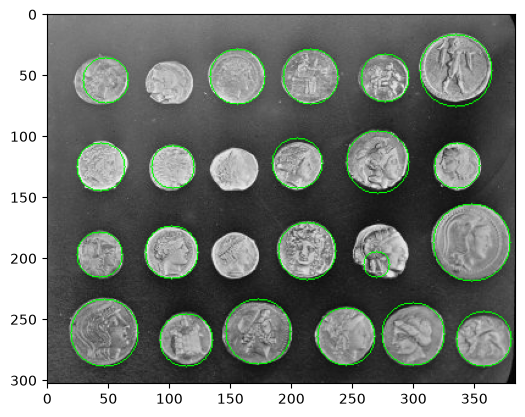

In [148]:
result = get_hough_circles(coins, n=40, g_k=5, th1=75, th2=200, radii= range(10, 35, 1), min_dist=55)
plt.imshow(result)